# Hospital Operations Analysis

---
## Sources & links 

Kaggle Dataset : [Hospital Management Dataset](https://www.kaggle.com/datasets/kanakbaghel/hospital-management-dataset?select=appointments.csv)

Website used to create ERD : [dbdiagram.io](https://dbdiagram.io/home)

---
## Overview 
- title 
- sources & links
- overview
- figures
- imports
    - library imports
    - data imports
- business understanding 
    - business objectives 
    - situation assesment 
    - project plan
- data understanding
    - data properties 
    - ERD
- methodology
- functions
- database management
    - clear old database 
    - create database connection
    - create tables
    - data insertion & validation
- business questions & analysis
    - executive performance
    - branch performace 
    - operations
    - financial performance 
    - patient demographics 

--- 
## Figures

- Figure 1. Entity Relationship Diagram (ERD) of the hospital operations database.
- Figure 2. Monthly revenue for the calandar year of 2023.
- Figure 3. Revenue per branch.
- Figure 4. Average Revenue Per Patient
- Figure 5. Monthly Revenue by Hospital Branch

---
## Imports

### Library Imports

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

In [2]:
# this cell is to show the last update to this notebook
now = datetime.now()
print(f'This notebook was last updated at : {now} PST')

This notebook was last updated at : 2026-07-23 14:22:03.167711 PST


### Data Imports 

In [3]:
patients_df = pd.read_csv('operations_data/patients.csv')
doctors_df = pd.read_csv('operations_data/doctors.csv')
appointments_df = pd.read_csv('operations_data/appointments.csv')
billing_df = pd.read_csv('operations_data/billing.csv')
treatment_df = pd.read_csv('operations_data/treatments.csv')

In [4]:
patients_df.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [5]:
doctors_df.head()

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [6]:
appointments_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [7]:
billing_df.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending


In [8]:
treatment_df.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


---
## Business Understanding 

---
## Data Understanding

### Data Properties

### ERD 

This hospital database consists of five normalized tables that model the relationships between patients, doctors, appointments, treatments, and billing records. As shown in Figure 1, an ERD illustrates the database structure and foreign key relationships.

>Figure 1. Entity Relationship Diagram (ERD) of the hospital operations database.

<img src="assets/hospital_erd.png" width="700">

---
## Methodology

---
## Functions

---
## Database Management 
Here we are firstly going to clear this notebooks database, as this prevents data being du

In [9]:
# delete old database
db_path = Path('hospital.db')

if db_path.exists():
    db_path.unlink()

Then create an empty database for us to add tables and eventually populate those tables with the data from the `.csv` file. This is done this way so we can have much more control over the database. 

In [10]:
conn = sqlite3.connect('hospital.db')
conn.execute('PRAGMA foreign_keys = ON')

### Tables
Here we create empty tables with the constraints we want for each data point. We will also be creating smaller dataframes for each table to pull data from so we can only use the data from each table we want. 

In [11]:
# patients table
conn.execute("""
CREATE TABLE patients (
patient_id TEXT PRIMARY KEY,
first_name TEXT,
last_name TEXT,
gender TEXT,
date_of_birth TEXT
);
""")

In [12]:
patients_sql = patients_df[['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth']]

In [13]:
patients_sql.head()

,patient_id,first_name,last_name,gender,date_of_birth
0,P001,David,Williams,F,1955-06-04
1,P002,Emily,Smith,F,1984-10-12
2,P003,Laura,Jones,M,1977-08-21
3,P004,Michael,Johnson,F,1981-02-20
4,P005,David,Wilson,M,1960-06-23


In [14]:
# doctors table
conn.execute("""
CREATE TABLE doctors (
doctor_id TEXT PRIMARY KEY,
first_name TEXT,
last_name TEXT,
specialization TEXT,
hospital_branch TEXT
);
""")

In [15]:
doctors_sql = doctors_df [['doctor_id', 'first_name', 'last_name', 'specialization', 'hospital_branch']]

In [16]:
doctors_sql.head()

,doctor_id,first_name,last_name,specialization,hospital_branch
0,D001,David,Taylor,Dermatology,Westside Clinic
1,D002,Jane,Davis,Pediatrics,Eastside Clinic
2,D003,Jane,Smith,Pediatrics,Eastside Clinic
3,D004,David,Jones,Pediatrics,Central Hospital
4,D005,Sarah,Taylor,Dermatology,Central Hospital


In [17]:
# appointmets table
conn.execute("""
CREATE TABLE appointments (
appointment_id TEXT PRIMARY KEY,
patient_id TEXT,
doctor_id TEXT,
appointment_date TEXT,
status TEXT,
reason_for_visit TEXT,

FOREIGN KEY(patient_id)
    REFERENCES patients(patient_id),
FOREIGN KEY(doctor_id)
    REFERENCES doctors(doctor_id)
);
""")

In [18]:
appointments_sql = appointments_df [['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'status', 'reason_for_visit']]

In [19]:
appointments_sql.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,reason_for_visit
0,A001,P034,D009,2023-08-09,Scheduled,Therapy
1,A002,P032,D004,2023-06-09,No-show,Therapy
2,A003,P048,D004,2023-06-28,Cancelled,Consultation
3,A004,P025,D006,2023-09-01,Cancelled,Consultation
4,A005,P040,D003,2023-07-06,No-show,Emergency


In [20]:
# billing table
conn.execute("""
CREATE TABLE billing (
bill_id TEXT PRIMARY KEY,
patient_id TEXT,
treatment_id TEXT,
bill_date TEXT,
amount REAL,

FOREIGN KEY(patient_id)
    REFERENCES patients(patient_id),
FOREIGN KEY(treatment_id)
    REFERENCES treatments(treatment_id)
);
""")

In [21]:
billing_sql = billing_df[['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount']]

In [22]:
billing_sql.head()

,bill_id,patient_id,treatment_id,bill_date,amount
0,B001,P034,T001,2023-08-09,3941.97
1,B002,P032,T002,2023-06-09,4158.44
2,B003,P048,T003,2023-06-28,3731.55
3,B004,P025,T004,2023-09-01,4799.86
4,B005,P040,T005,2023-07-06,582.05


In [23]:
# treatment table
conn.execute("""
CREATE TABLE treatments (
treatment_id TEXT PRIMARY KEY,
appointment_id TEXT NOT NULL,
treatment_type TEXT,
description TEXT,
treatment_date TEXT,

FOREIGN KEY(appointment_id)
    REFERENCES appointments(appointment_id)
);
""")

In [24]:
treatment_sql = treatment_df[['treatment_id', 'appointment_id', 'treatment_type', 'description', 'treatment_date']]

In [25]:
treatment_sql.head()

,treatment_id,appointment_id,treatment_type,description,treatment_date
0,T001,A001,Chemotherapy,Basic screening,2023-08-09
1,T002,A002,MRI,Advanced protocol,2023-06-09
2,T003,A003,MRI,Standard procedure,2023-06-28
3,T004,A004,MRI,Basic screening,2023-09-01
4,T005,A005,ECG,Standard procedure,2023-07-06


### Data Insertion
Here we are populating our tables, then using the output below the insertion to validate it worked properly.

In [26]:
# patients table
patients_sql.to_sql(
    'patients',
    conn,
    if_exists = 'append',
    index = False
)

50

In [27]:
# validation
pd.read_sql("""
SELECT COUNT(*) as total_patients
FROM patients
""", conn)

,total_patients
0,50


In [28]:
pd.read_sql("""
SELECT *
FROM patients
LIMIT 5
""", conn)

,patient_id,first_name,last_name,gender,date_of_birth
0,P001,David,Williams,F,1955-06-04
1,P002,Emily,Smith,F,1984-10-12
2,P003,Laura,Jones,M,1977-08-21
3,P004,Michael,Johnson,F,1981-02-20
4,P005,David,Wilson,M,1960-06-23


In [29]:
# doctors table
doctors_sql.to_sql(
    'doctors',
    conn,
    if_exists = 'append',
    index = False
)

10

In [30]:
# validation
pd.read_sql("""
SELECT COUNT(*) as total_doctors
FROM doctors
""", conn)

,total_doctors
0,10


In [31]:
pd.read_sql("""
SELECT * 
FROM doctors
LIMIT 5
""", conn)

,doctor_id,first_name,last_name,specialization,hospital_branch
0,D001,David,Taylor,Dermatology,Westside Clinic
1,D002,Jane,Davis,Pediatrics,Eastside Clinic
2,D003,Jane,Smith,Pediatrics,Eastside Clinic
3,D004,David,Jones,Pediatrics,Central Hospital
4,D005,Sarah,Taylor,Dermatology,Central Hospital


In [32]:
# appointments table
appointments_sql.to_sql(
    'appointments',
    conn,
    if_exists = 'append',
    index = False
)

200

In [33]:
# validation
pd.read_sql("""
SELECT COUNT(*) as total_appointments
FROM appointments
""", conn)

,total_appointments
0,200


In [34]:
pd.read_sql("""
select *
FROM appointments
LIMIT 5
""", conn)

,appointment_id,patient_id,doctor_id,appointment_date,status,reason_for_visit
0,A001,P034,D009,2023-08-09,Scheduled,Therapy
1,A002,P032,D004,2023-06-09,No-show,Therapy
2,A003,P048,D004,2023-06-28,Cancelled,Consultation
3,A004,P025,D006,2023-09-01,Cancelled,Consultation
4,A005,P040,D003,2023-07-06,No-show,Emergency


In [35]:
# treatments table
treatment_sql.to_sql(
    'treatments',
    conn,
    if_exists = 'append', 
    index = False
)

200

In [36]:
# validation
pd.read_sql("""
select COUNT(*) as total_treatments
from treatments
""", conn)

,total_treatments
0,200


In [37]:
pd.read_sql("""
select *
from treatments
limit 5
""", conn)

,treatment_id,appointment_id,treatment_type,description,treatment_date
0,T001,A001,Chemotherapy,Basic screening,2023-08-09
1,T002,A002,MRI,Advanced protocol,2023-06-09
2,T003,A003,MRI,Standard procedure,2023-06-28
3,T004,A004,MRI,Basic screening,2023-09-01
4,T005,A005,ECG,Standard procedure,2023-07-06


In [38]:
# billing table 
billing_sql.to_sql(
    'billing',
    conn,
    if_exists = 'append',
    index = False
)

200

In [39]:
# validation
pd.read_sql("""
select COUNT(*) as total_bills
from billing
""", conn)

,total_bills
0,200


In [40]:
pd.read_sql("""
select *
from billing
limit 5
""", conn)

,bill_id,patient_id,treatment_id,bill_date,amount
0,B001,P034,T001,2023-08-09,3941.97
1,B002,P032,T002,2023-06-09,4158.44
2,B003,P048,T003,2023-06-28,3731.55
3,B004,P025,T004,2023-09-01,4799.86
4,B005,P040,T005,2023-07-06,582.05


In [41]:
conn.commit()

With the database successfully constructed and validated, the following analysis uses SQL and Python to answer key business questions regarding hospital performance.

---
## Business Questions & Analysis

### Executive Performance 
_Is the organization healthy_

The following analysis evaluates the overall operational and financial performance of the hospital network by examining key executive performance indicators.

In [42]:
# what is total revenue

total_income = pd.read_sql("""
select sum(amount) as total_income
from billing
""", conn)

In [43]:
total_income.style.format({
    'total_income' : "${:,.2f}"
})

,total_income
0,"$551,249.85"


In [44]:
# how many patients were treated

pd.read_sql("""
select count(*) as total_patients
from patients
""", conn)

,total_patients
0,50


In [45]:
# how many appointments were made

pd.read_sql("""
select count(*) as total_appointments
from appointments
""", conn)

,total_appointments
0,200


In [46]:
# what is the average spent per patient

per_pt = pd.read_sql("""
select sum(amount) / count(amount) as average_per_patient
from billing
""", conn)

In [47]:
per_pt.style.format({
    'average_per_patient' : "${:,.2f}"
})

,average_per_patient
0,"$2,756.25"


In [48]:
# revenue over time

monthly_revenue = pd.read_sql("""
select strftime('%Y-%m', bill_date) as month,
sum(amount) as revenue
from billing
group by month
order by month
""", conn)

In [49]:
monthly_revenue.style.format({
    'revenue' : "${:,.2f}"
})

,month,revenue
0,2023-01,"$58,701.23"
1,2023-02,"$36,669.69"
2,2023-03,"$47,304.29"
3,2023-04,"$64,271.54"
4,2023-05,"$48,791.05"
5,2023-06,"$56,887.82"
6,2023-07,"$39,880.19"
7,2023-08,"$41,958.67"
8,2023-09,"$33,426.53"
9,2023-10,"$43,314.15"


Using the charts generated above, we can see that for the year 2023, we had 50 patients, resulting in an income of 551,249 across 200 total appointments, with an average spent per patient sitting at 2,756.

The charts above are a little hard to read when it comes to seeing the trend over time. Let's make a line chart to better visualize the revenue for 2023.

>Figure 2. Monthly revenue for the calandar year of 2023.

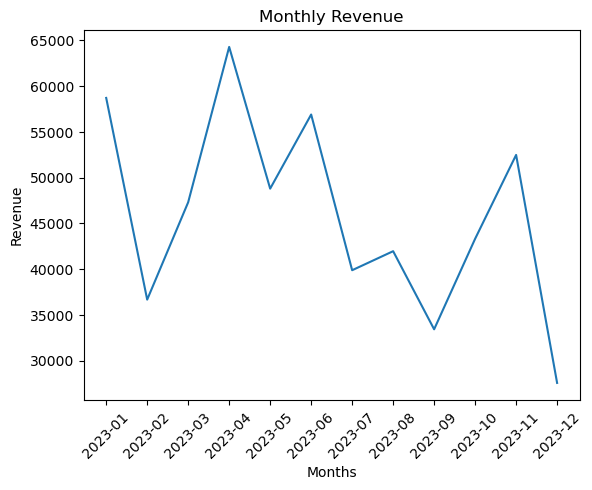

In [50]:
fig, ax = plt.subplots()

x = monthly_revenue['month']
y = monthly_revenue['revenue']

plt.plot(x,y)

plt.title('Monthly Revenue')
plt.xlabel('Months')
plt.ylabel('Revenue')

plt.xticks(rotation = 45)
plt.show();

### Insights

In [51]:
highest_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax()]
lowest_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmin()]
average_revenue = monthly_revenue['revenue'].mean()
highest_percent = (highest_month['revenue'] - average_revenue) / monthly_revenue['revenue'].mean() * 100
lowest_percent = abs((lowest_month['revenue'] - average_revenue) / monthly_revenue['revenue'].mean() * 100)

In [52]:
print(f'highest revenue month : {highest_month['month']} (${highest_month['revenue']:,.2f})')
print(f'lowest revenue month : {lowest_month['month']} (${lowest_month['revenue']:,.2f})')
print(f'average monthly revenue : ${average_revenue:,.2f}')
print(f'{highest_month['month']} is {highest_percent:.1f}% above the average')
print(f'{lowest_month['month']} is {lowest_percent:.1f}% below the average')

highest revenue month : 2023-04 ($64,271.54)
lowest revenue month : 2023-12 ($27,569.71)
average monthly revenue : $45,937.49
2023-04 is 39.9% above the average
2023-12 is 40.0% below the average


Monthly revenue fluctuated throughout 2023, with no sustained upward or downward trend. Revenue peaked in April at 64k, approximately 40% above the annual monthly average of 46k, while December recorded the lowest monthly revenue at 27k, 40% below the average. This variability suggests that seasonal demand, patient volume, treatment mix, or billing cycles may have influenced monthly financial perormance.

These fluctuations suggest that further analysis into branch performance, appointment volume, and treatment mix may help explain the variation observed throughout the year.

---
### Branch Performance

_Are the branches healthy_

The following analysis evaluates the overall operational and financial performance of each branch by examining key performance indicators.

In [53]:
pd.read_sql('''
select hospital_branch
from doctors
group by hospital_branch
order by hospital_branch
''', conn)

,hospital_branch
0,Central Hospital
1,Eastside Clinic
2,Westside Clinic


In [54]:
# which branch generates the most revenue 
hospital_branch_df = pd.read_sql('''
select d.hospital_branch, sum(amount) as total_revenue
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
join treatments as t
on a.appointment_id = t.appointment_id
join billing as b 
on t.treatment_id = b.treatment_id
group by d.hospital_branch
order by total_revenue desc
''', conn)

In [55]:
hospital_branch_df.style.format({
    'total_revenue' : "${:,.2f}"
})

,hospital_branch,total_revenue
0,Central Hospital,"$229,039.44"
1,Eastside Clinic,"$162,031.10"
2,Westside Clinic,"$160,179.31"


>Figure 3. Revenue per branch.

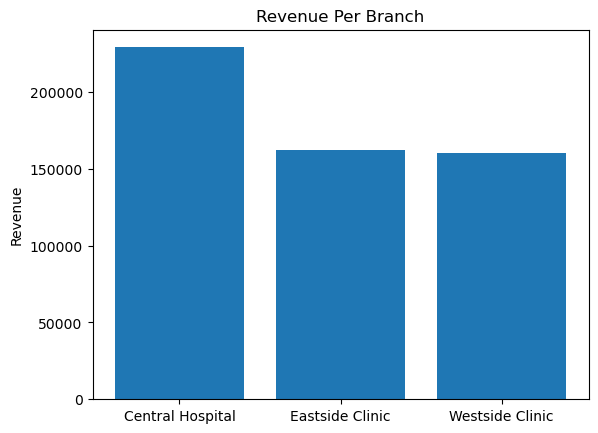

In [56]:
fig, ax = plt.subplots()

x = hospital_branch_df['hospital_branch']
y = hospital_branch_df['total_revenue']

plt.bar(x,y)

plt.title('Revenue Per Branch')
plt.ylabel('Revenue')

plt.show();

In [57]:
# which branch sees the most patients
pd.read_sql('''
select d.hospital_branch, count(distinct(a.patient_id)) as total_patients
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
group by d.hospital_branch
order by total_patients desc
''', conn)

,hospital_branch,total_patients
0,Central Hospital,39
1,Westside Clinic,36
2,Eastside Clinic,34


In the above graph, we can see that Central Hospital has the most total patients, with Westside and Eastside Hospital following closely behind. These totals are greater then the total amount of patients treated due to the fact a single patient can visit many hospitals. The success of Central Hospital is likely due its location, allowing for a wider reach of people who choose this location, resulting in higher patient count and higher total income.

In [58]:
# which branch has the highest average revenue per patient
branch_revenue = pd.read_sql('''
select d.hospital_branch, sum(b.amount) as total_revenue,
count(distinct(a.patient_id)) as unique_patients,
round(sum(b.amount) * 1.0 / count(distinct(a.patient_id)), 2) as revenue_per_patient
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
join treatments as t
on a.appointment_id = t.appointment_id
join billing as b
on t.treatment_id = b.treatment_id
group by d.hospital_branch
order by revenue_per_patient desc
''', conn)

In [59]:
branch_revenue.style.format({
    'total_revenue': "${:,.2f}",
    'revenue_per_patient' : "${:,.2f}",
    'unique_patients' : "{:,}"
})

,hospital_branch,total_revenue,unique_patients,revenue_per_patient
0,Central Hospital,"$229,039.44",39,"$5,872.81"
1,Eastside Clinic,"$162,031.10",34,"$4,765.62"
2,Westside Clinic,"$160,179.31",36,"$4,449.43"


>Figure 4. Average Revenue Per Patient

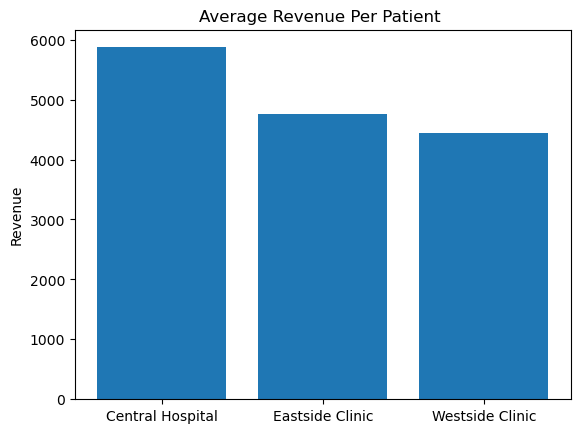

In [60]:
fig, ax = plt.subplots()

x = branch_revenue['hospital_branch']
y = branch_revenue['revenue_per_patient']

plt.bar(x,y)

plt.title('Average Revenue Per Patient ')
plt.ylabel('Revenue')

plt.show();

As seen in Figure 4, Central Hospital also has the highest revenue per patient which corrisponds to having the most patients throughout the year, as well as implying that potentially Central Hospital also offers higher costing treatments and services. 

In [61]:
# branch growth over the year
branch_trends = pd.read_sql('''
select d.hospital_branch, strftime('%m', b.bill_date) as month_number,
strftime('%m', b.bill_date) ||"-"||
case strftime('%m', b.bill_date)
    when '01' then 'jan'
    when '02' then 'Feb'
    when '03' then 'Mar'
    when '04' then 'Apr'
    when '05' then 'May'
    when '06' then 'Jun'
    when '07' then 'Jul'
    when '08' then 'Aug' 
    when '09' then 'Sept'
    when '10' then 'Oct'
    when '11' then 'Nov'
    when '12' then 'Dec'
end as month,
sum(amount) as total_revenue
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
join treatments as t
on a.appointment_id = t.appointment_id
join billing as b
on t.treatment_id = b.treatment_id
group by d.hospital_branch,
month_number
order by month_number,
d.hospital_branch
''', conn)

>Figure 5. Monthly Revenue by Hospital Branch

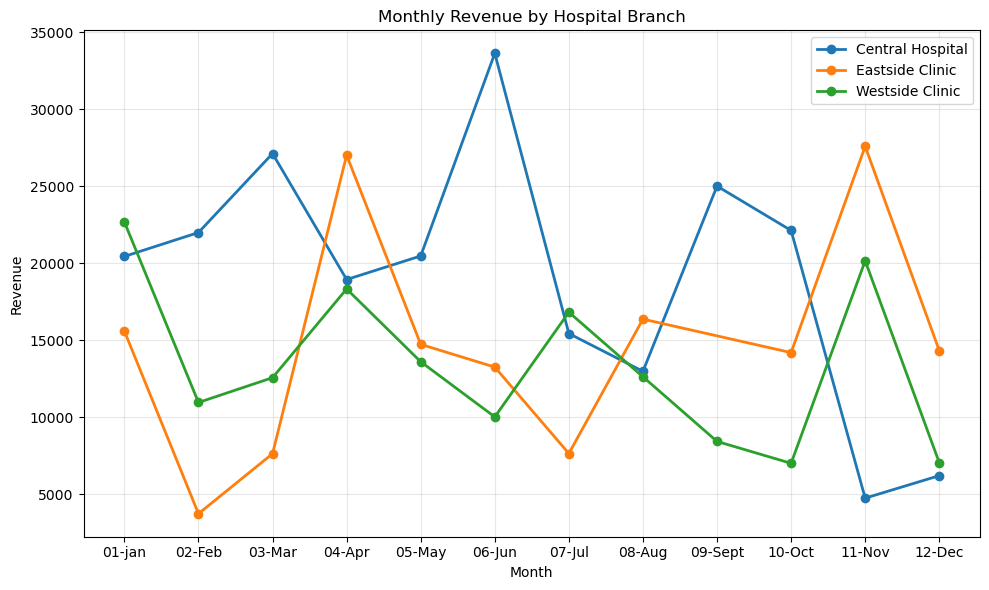

In [62]:
plt.figure(figsize=(10,6))

for branch in branch_trends["hospital_branch"].unique():

    df = branch_trends[
        branch_trends["hospital_branch"] == branch
    ]

    plt.plot(
        df["month"],
        df["total_revenue"],
        marker="o",
        linewidth=2,
        label=branch
    )

plt.title("Monthly Revenue by Hospital Branch")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show();

This plot also shows the same pattern as Figure 2, with a fluctuating revenue resulting in no upward or downward trend.

- Central Hospital
    - highest earner in February, March, May, June and September - 5 months of the year
    - June had the highest revenue, sitting around 33K
    - sharp drop in July 
    - significant decline is from October to November, from roughly 22K to a little under 5K
    - Novemebr and December are the low points 
- Eeastside Clinic 
    - highest earner in April, August, November and December - 4 months of the year
    - lowest start of the year at 16K
    - hits the lowest of all locations thoughout the year in Feruary at 3K
    - sharp rise in April up to 27K
    - sustained drop from april to July, reaching 7K
    - slight improvement in august with a small drop to October
    - highest point reaching roughly 27.5K
- Westside Clinic
    - highest earner in January, and July - 2 months of the year
    - started the highest of the year at 23K
    - steep drop in february
    - slow rise in March and sharp increase to April
    - slow decrease from Arpil to July
    - average revenue from August to October
    - sharp increase again in November to 27K, followed by a sharp fall in December

June and November and the 2 months needing furthur investigation. In June, Central hospital hit its peak, well above the clininc locations, as well was the only location with an increase that month. In November, the revenue was the opposite, with Westside and Eastside clinic both having similar peaks, while Central Hospital dipped to their lowest. These trends could be due to appointment volume, treatment mix, billing activity and cycles, or a mixture of it all.